# Transformer para retornos diarios (comparable con el anexo)

**TFG — Enrique Crespillo Ramos.** Este notebook entrena **un unico
modelo**, un Transformer de auto-atencion con RevIN, sobre las series
diarias (AAPL, JPM, JNJ, XOM y Bitcoin) en horizontes de 1 y 5 dias.

## Objetivo: comparar con `anexo_codigo`

El Transformer se ejecuta con **el mismo protocolo que el anexo** para
que sus cifras sean directamente comparables con las filas de
`metricas_regresion_v4.csv` (Naive, ARIMA, Random Forest, XGBoost, LSTM):

- **Mismas variables** (`add_features_v3` + semanales + VIX) y la misma
  seleccion del anexo (grupo `XGB_LSTM` de `features_seleccionadas_v4`).
- **Misma particion**: train <= 2022-12-31, val = 2023, test >= 2024.
- **Mismo walk-forward**: reentreno cada `RETRAIN_EVERY = 60` pasos del
  test, igual que `run_lstm`.
- **Mismo escalado**: `StandardScaler` ajustado sobre train+val, como la
  LSTM del anexo (asi el Transformer es un reemplazo directo del nucleo
  recurrente por auto-atencion, con todo lo demas fijo).
- **Mismas metricas**: RMSE, MAE, R2 y precision direccional (DA) con
  intervalos bootstrap al 95 %, y test de Diebold-Mariano frente al Naive.
- **Mismo `seq_len = 10`** que la LSTM del anexo.

La seccion final cruza el resultado del Transformer con la tabla del
anexo y deja un CSV (`Resultados/transformers_metricas.csv`) con el mismo
esquema de columnas, listo para anadir como una fila mas.

## Por que esta arquitectura

Con ~2.000 observaciones de entrenamiento por activo, un Transformer
grande sobreajusta. Se usa un encoder **compacto y muy regularizado**
(`d_model=64`, 2 capas, 4 cabezas, FFN 128, dropout 0,3, *weight decay*,
recorte de gradiente, parada temprana) con **RevIN** para los cambios de
regimen de volatilidad. La eleccion sigue a Zeng et al. (2023), Kim et
al. (2022) y Andreoletti (2026); la justificacion completa esta en la
seccion 12.

> **PyTorch.** Es el estandar en la investigacion de Transformers para
> series. La LSTM del anexo esta en Keras; aqui el bucle de entreno es
> otro, pero el protocolo (features, particion, walk-forward, escalado,
> metricas) es identico, que es lo que hace comparables las cifras.

## 0. Configuracion y dependencias

En Colab, descomenta el `pip install` y ajusta `BASE_DIR` a la carpeta
del TFG (la que contiene `Datos/` y `Resultados/`).

In [1]:
# En Colab, descomenta:
# !pip install torch xgboost dieboldmariano yfinance -q

In [2]:
import os
import copy
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings('ignore')

import torch
import torch.nn as nn

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (mean_squared_error,
                             mean_absolute_error, r2_score)

try:
    import yfinance as yf
    YF_OK = True
except Exception:
    YF_OK = False

try:
    from dieboldmariano import dm_test
    DM_OK = True
except Exception:
    DM_OK = False

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
DEVICE = ('cuda' if torch.cuda.is_available() else 'cpu')

print('PyTorch :', torch.__version__)
print('Device  :', DEVICE)
print('yfinance:', 'OK' if YF_OK else 'NO')
print('DM test :', 'OK' if DM_OK else 'NO (pip install dieboldmariano)')

PyTorch : 2.12.0+cpu
Device  : cpu
yfinance: OK
DM test : OK


In [5]:
BASE_DIR = Path(r'C:\Users\enris\Desktop\UNIVERSIDAD\Cuarto\TFG')

# BASE_DIR = Path('/content/drive/MyDrive/TFG')

DIR_STOCKS  = BASE_DIR / 'Datos' / 'Stocks'
DIR_BTC     = BASE_DIR / 'Datos' / 'BTC'
RESULTS_DIR = BASE_DIR / 'Resultados'
FIGURES_DIR = BASE_DIR / 'Figuras'
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
print('BASE_DIR :', BASE_DIR)
print('Datos OK :', DIR_STOCKS.exists() and DIR_BTC.exists())

BASE_DIR : C:\Users\enris\Desktop\UNIVERSIDAD\Cuarto\TFG
Datos OK : True


In [6]:
# Configuracion (alineada con el anexo para que sea comparable)
STOCK_TICKERS = ['AAPL', 'JPM', 'JNJ', 'XOM']
ALL_TICKERS   = STOCK_TICKERS + ['BTC']
HORIZONS      = ['1d', '5d']

TRAIN_END = '2022-12-31'
VAL_END   = '2023-12-31'

SEQ_LEN       = 10     # mismo que la LSTM del anexo
RETRAIN_EVERY = 60     # walk-forward, mismo que el anexo
WALK_FORWARD  = True   # False = un solo fit estatico (mas rapido)
USE_VIX       = True   # features del VIX en las acciones (como el anexo)
USE_REVIN     = True
SEEDS         = [7, 42, 123]   # robustez multi-semilla

# Arquitectura del Transformer
TF_DMODEL, TF_HEADS, TF_LAYERS = 64, 4, 2
TF_FF, TF_DROPOUT = 128, 0.3

# Entrenamiento
EPOCHS, BATCH = 100, 32
LR, WDECAY = 1e-3, 1e-2
PATIENCE, CLIP = 12, 1.0
REFIT_EPOCHS = 15      # epocas en cada reentreno del walk-forward
print('Configuracion cargada. Walk-forward =', WALK_FORWARD)

Configuracion cargada. Walk-forward = True


## 1. Carga de datos

Mismas funciones que el anexo.

In [7]:
def load_stock(ticker):
    path = DIR_STOCKS / f'{ticker}_2015_2026.csv'
    df = pd.read_csv(path, parse_dates=['Date'], index_col='Date')
    df.columns = [c.lower() for c in df.columns]
    df = df.rename(columns={'close':'Close','open':'Open',
                            'high':'High','low':'Low',
                            'volume':'Volume'})
    return df[['Open','High','Low','Close','Volume']].sort_index()


def load_btc():
    path = DIR_BTC / 'btc_1d_data_2018_to_2025.csv'
    df = pd.read_csv(path)
    df['Date'] = pd.to_datetime(
        df['Open time'].str.replace(' UTC', '', regex=False))
    df = df.set_index('Date').sort_index()
    return df[['Open','High','Low','Close','Volume']].astype(float)


raw = {t: load_stock(t) for t in STOCK_TICKERS}
raw['BTC'] = load_btc()
for t in ALL_TICKERS:
    df = raw[t]
    print(f'{t:5s}: {len(df):,} sesiones  |  '
          f'{df.index[0].date()} - {df.index[-1].date()}')

AAPL : 2,815 sesiones  |  2015-01-02 - 2026-03-13
JPM  : 2,815 sesiones  |  2015-01-02 - 2026-03-13
JNJ  : 2,815 sesiones  |  2015-01-02 - 2026-03-13
XOM  : 2,815 sesiones  |  2015-01-02 - 2026-03-13
BTC  : 2,997 sesiones  |  2018-01-01 - 2026-03-16


## 2. Ingenieria de variables

Bloque base, regimen de volatilidad y VIX. Identico al anexo.

In [8]:
VIX_FEATURES = ['VIX_Close', 'VIX_Return_1d',
                'VIX_SMA_20', 'VIX_vs_SMA20']


def download_vix():
    if not (USE_VIX and YF_OK):
        return None
    try:
        v = yf.download('^VIX', start='2014-01-01',
                        end='2026-06-01', progress=False)
        if isinstance(v.columns, pd.MultiIndex):
            v.columns = v.columns.get_level_values(0)
        v = v[['Close']].rename(columns={'Close':'VIX_Close'})
        v.index = pd.to_datetime(v.index)
        v['VIX_Return_1d'] = v['VIX_Close'].pct_change()
        v['VIX_SMA_20']    = v['VIX_Close'].rolling(20).mean()
        v['VIX_vs_SMA20']  = v['VIX_Close'] / v['VIX_SMA_20'] - 1
        print(f'VIX: {len(v):,} sesiones descargadas.')
        return v
    except Exception as e:
        print('Aviso: VIX no disponible, se omite.', e)
        return None


vix_raw = download_vix()
HAS_VIX = vix_raw is not None

VIX: 3,121 sesiones descargadas.


In [9]:
def add_features_v3(df, vix_df=None):
    d = df.copy()
    d['Return_1d']  = d['Close'].pct_change(1)
    d['Return_5d']  = d['Close'].pct_change(5)
    d['Return_10d'] = d['Close'].pct_change(10)
    d['Return_20d'] = d['Close'].pct_change(20)

    for w in [20, 50, 200]:
        d[f'SMA_{w}'] = d['Close'].rolling(w).mean()
    ema12 = d['Close'].ewm(span=12, adjust=False).mean()
    ema26 = d['Close'].ewm(span=26, adjust=False).mean()

    d['Price_vs_SMA20']  = d['Close'] / d['SMA_20']  - 1
    d['Price_vs_SMA50']  = d['Close'] / d['SMA_50']  - 1
    d['Price_vs_SMA200'] = d['Close'] / d['SMA_200'] - 1

    d['MACD']        = ema12 - ema26
    d['MACD_Signal'] = d['MACD'].ewm(span=9, adjust=False).mean()
    d['MACD_Hist']   = d['MACD'] - d['MACD_Signal']

    delta = d['Close'].diff()
    gain  = delta.clip(lower=0).rolling(14).mean()
    loss  = (-delta.clip(upper=0)).rolling(14).mean()
    d['RSI_14'] = 100 - (100 / (1 + gain / loss.replace(0, np.nan)))

    bb_mid = d['Close'].rolling(20).mean()
    bb_std = d['Close'].rolling(20).std()
    bb_up  = bb_mid + 2 * bb_std
    bb_lo  = bb_mid - 2 * bb_std
    d['BB_Width']    = (bb_up - bb_lo) / bb_mid
    d['BB_Position'] = (d['Close'] - bb_lo) / (bb_up - bb_lo + 1e-8)

    tr = pd.concat([
        d['High'] - d['Low'],
        (d['High'] - d['Close'].shift(1)).abs(),
        (d['Low']  - d['Close'].shift(1)).abs()], axis=1).max(axis=1)
    d['ATR_rel'] = tr.ewm(com=13, adjust=False).mean() / d['Close']

    d['Momentum_5']  = d['Close'] - d['Close'].shift(5)
    d['Momentum_10'] = d['Close'] - d['Close'].shift(10)

    d['Vol_20d']   = d['Return_1d'].rolling(20).std()
    d['Vol_rel']   = (d['Volume']
                      / (d['Volume'].rolling(20).mean() + 1e-8))
    d['Day_Range'] = (d['High'] - d['Low']) / d['Close']

    vol5  = d['Return_1d'].rolling(5).std()
    vol10 = d['Return_1d'].rolling(10).std()
    vol60 = d['Return_1d'].rolling(60).std()
    d['Vol_ratio_5_20']  = vol5  / (d['Vol_20d'] + 1e-8)
    d['Vol_ratio_10_60'] = vol10 / (vol60 + 1e-8)
    d['Vol_percentile_60'] = d['Vol_20d'].rolling(60).apply(
        lambda x: pd.Series(x).rank(pct=True).iloc[-1], raw=False)
    vol20_m = d['Vol_20d'].rolling(60).mean()
    vol20_s = d['Vol_20d'].rolling(60).std()
    d['Vol_zscore_60'] = (d['Vol_20d'] - vol20_m) / (vol20_s + 1e-8)

    log_hl = np.log(d['High'] / d['Low'])
    log_co = np.log(d['Close'] / d['Open'])
    gk = 0.5 * log_hl**2 - (2*np.log(2) - 1) * log_co**2
    d['Garman_Klass_vol'] = np.sqrt(gk.rolling(20).mean() * 252)
    d['Parkinson_vol'] = np.sqrt(
        (1 / (4*np.log(2)))
        * (np.log(d['High']/d['Low'])**2).rolling(20).mean() * 252)
    d['Vol_of_vol'] = d['Vol_20d'].rolling(20).std()
    vol_rel_60 = (d['Vol_20d']
                  / (d['Vol_20d'].rolling(60).mean() + 1e-8))
    d['Volume_vol_ratio'] = d['Vol_rel'] / (vol_rel_60 + 1e-8)

    if vix_df is not None:
        d = d.join(vix_df[VIX_FEATURES], how='left')
        for col in VIX_FEATURES:
            d[col] = d[col].ffill()
    for c in ['SMA_20', 'SMA_50', 'SMA_200']:
        d.drop(columns=[c], errors='ignore', inplace=True)
    return d


_BASE = [
    'Return_1d','Return_5d','Return_10d','Return_20d',
    'Price_vs_SMA20','Price_vs_SMA50','Price_vs_SMA200',
    'MACD','MACD_Signal','MACD_Hist','RSI_14',
    'BB_Width','BB_Position','ATR_rel',
    'Momentum_5','Momentum_10','Vol_20d','Vol_rel','Day_Range',
    'Vol_ratio_5_20','Vol_ratio_10_60','Vol_percentile_60',
    'Vol_zscore_60','Garman_Klass_vol','Parkinson_vol',
    'Vol_of_vol','Volume_vol_ratio']
FEATURE_COLS_STOCKS = _BASE + (VIX_FEATURES if HAS_VIX else [])
FEATURE_COLS_BTC    = _BASE

data = {}
for t in STOCK_TICKERS:
    data[t] = add_features_v3(raw[t],
                              vix_df=vix_raw if HAS_VIX else None)
data['BTC'] = add_features_v3(raw['BTC'], vix_df=None)
print(f'Features acciones: {len(FEATURE_COLS_STOCKS)}  |  '
      f'BTC: {len(FEATURE_COLS_BTC)}')

Features acciones: 31  |  BTC: 27


In [10]:
def add_weekly_features(df):
    d = df.copy()
    logret = np.log(d['Close'] / d['Close'].shift(1))
    d['Return_5d_lag1'] = logret.rolling(5).sum().shift(1)
    d['Vol_5d']         = logret.rolling(5).std()
    d['Momentum_5d']    = d['Close'].pct_change(5)
    delta = d['Close'].diff()
    gain  = delta.clip(lower=0).rolling(5).mean()
    loss  = (-delta.clip(upper=0)).rolling(5).mean()
    d['RSI_5d'] = 100 - (100 / (1 + gain / loss.replace(0, np.nan)))
    d['Vol_mean_5d'] = (d['Volume'].rolling(5).mean()
                        / (d['Volume'].rolling(20).mean() + 1e-8))
    return d


WEEKLY_FEATURES = ['Return_5d_lag1', 'Vol_5d', 'Momentum_5d',
                   'RSI_5d', 'Vol_mean_5d']
print('Features semanales (5d):', WEEKLY_FEATURES)

Features semanales (5d): ['Return_5d_lag1', 'Vol_5d', 'Momentum_5d', 'RSI_5d', 'Vol_mean_5d']


## 3. Dataset y particion temporal

Objetivo: retorno logaritmico futuro. Particion estrictamente
cronologica. Para 5 dias se anaden las cinco variables semanales.

In [11]:
def prepare_dataset(df, feature_cols):
    d = df.copy()
    d['logret']    = np.log(d['Close'] / d['Close'].shift(1))
    d['target_1d'] = d['logret'].shift(-1)
    d['target_5d'] = np.log(d['Close'].shift(-5) / d['Close'])
    d = add_weekly_features(d)
    feats_1d = [c for c in feature_cols if c in d.columns]
    feats_5d = feats_1d + [c for c in WEEKLY_FEATURES
                           if c in d.columns]
    all_cols = list(set(feats_5d + ['target_1d', 'target_5d']))
    d = d.dropna(subset=all_cols)
    train = d.loc[:TRAIN_END]
    val   = d.loc[TRAIN_END:VAL_END].iloc[1:]
    test  = d.loc[VAL_END:].iloc[1:]
    out = {'feature_cols_1d': feats_1d, 'feature_cols_5d': feats_5d}
    for name, part in [('train', train), ('val', val),
                       ('test', test)]:
        out[f'X_{name}_1d'] = part[feats_1d]
        out[f'X_{name}_5d'] = part[feats_5d]
        out[f'y_{name}_1d'] = part['target_1d']
        out[f'y_{name}_5d'] = part['target_5d']
        out[f'idx_{name}']  = part.index
    return out


datasets = {}
for t in STOCK_TICKERS:
    datasets[t] = prepare_dataset(data[t], FEATURE_COLS_STOCKS)
datasets['BTC'] = prepare_dataset(data['BTC'], FEATURE_COLS_BTC)

print(f"{'Ticker':<8}{'Train':>7}{'Val':>7}{'Test':>7}"
      f"{'F.1d':>7}{'F.5d':>7}")
print('-' * 45)
for t in ALL_TICKERS:
    ds = datasets[t]
    print(f"{t:<8}{len(ds['X_train_1d']):>7}"
          f"{len(ds['X_val_1d']):>7}{len(ds['X_test_1d']):>7}"
          f"{len(ds['feature_cols_1d']):>7}"
          f"{len(ds['feature_cols_5d']):>7}")

Ticker    Train    Val   Test   F.1d   F.5d
---------------------------------------------
AAPL       1732    245    517     31     36
JPM        1745    231    512     31     36
JNJ        1750    237    511     31     36
XOM        1753    237    521     31     36
BTC        1577    356    774     27     32


In [12]:
# Seleccion del anexo (grupo XGB_LSTM): mismas entradas que la LSTM.
def load_selected_feats():
    path = RESULTS_DIR / 'features_seleccionadas_v4.csv'
    if not path.exists():
        print('Aviso: features_seleccionadas_v4.csv no encontrado; '
              'se usan todas las variables.')
        return None
    fs = pd.read_csv(path)
    fs = fs[fs['Model_group'] == 'XGB_LSTM']
    sel = {}
    for (tk, hz), g in fs.groupby(['Ticker', 'Horizon']):
        sel[(tk, hz)] = list(g.sort_values('Rank')['Feature'])
    return sel


SELECTED = load_selected_feats()


def get_feat_idx(ticker, horizon):
    ds = datasets[ticker]
    all_feats = list(ds[f'feature_cols_{horizon}'])
    if SELECTED is not None and (ticker, horizon) in SELECTED:
        chosen = [f for f in SELECTED[(ticker, horizon)]
                  if f in all_feats]
        if chosen:
            return [all_feats.index(f) for f in chosen], chosen
    return list(range(len(all_feats))), all_feats

## 4. Secuencias y metricas

`create_sequences`, precision direccional, bootstrap y `evaluate_regression`
son los del anexo, asi las metricas se calculan igual.

In [13]:
def create_sequences(X, y, seq_len):
    Xs, ys = [], []
    for i in range(len(X) - seq_len + 1):
        Xs.append(X[i:i+seq_len])
        ys.append(y[i+seq_len-1])
    return np.array(Xs), np.array(ys)


def directional_accuracy(y_true, y_pred):
    y_true, y_pred = np.asarray(y_true), np.asarray(y_pred)
    mask = y_true != 0
    if mask.sum() == 0:
        return 0.0
    return np.mean(np.sign(y_pred[mask]) == np.sign(y_true[mask]))


def bootstrap_ci(y_true, y_pred, metric_fn, n_boot=1000, ci=0.95):
    rng = np.random.default_rng(42)
    n = len(y_true)
    vals = [metric_fn(y_true[idx], y_pred[idx])
            for idx in (rng.integers(0, n, n)
                        for _ in range(n_boot))]
    a = 1 - ci
    return (np.percentile(vals, 100*a/2),
            np.percentile(vals, 100*(1-a/2)))


def evaluate_regression(y_true, y_pred, model, ticker, horizon):
    yt = np.asarray(y_true, float)
    yp = np.asarray(y_pred, float)
    rmse = np.sqrt(mean_squared_error(yt, yp))
    rmse_ci = bootstrap_ci(
        yt, yp, lambda a, b: np.sqrt(mean_squared_error(a, b)))
    da = directional_accuracy(yt, yp)
    da_ci = bootstrap_ci(yt, yp, directional_accuracy)
    res = {'Model': model, 'Ticker': ticker, 'Horizon': horizon,
           'RMSE': rmse, 'RMSE_CI_low': rmse_ci[0],
           'RMSE_CI_high': rmse_ci[1],
           'MAE': mean_absolute_error(yt, yp),
           'R2': r2_score(yt, yp),
           'DA': da, 'DA_CI_low': da_ci[0], 'DA_CI_high': da_ci[1]}
    print(f"  {ticker:5s} {model:12s} {horizon:3s}  "
          f"RMSE {rmse:.6f}  DA {da:.3f} "
          f"[{da_ci[0]:.3f}, {da_ci[1]:.3f}]  R2 {res['R2']:+.4f}")
    return res

## 5. El Transformer

RevIN normaliza cada ventana por su media y desviacion (con afin
aprendible) para amortiguar los cambios de regimen de volatilidad. El
encoder es compacto: proyeccion lineal a `d_model`, posicion aprendible,
dos capas de auto-atencion, *pooling* de media y una cabeza lineal.

In [14]:
class RevIN(nn.Module):
    def __init__(self, n_features, eps=1e-5, affine=True):
        super().__init__()
        self.eps = eps
        self.affine = affine
        if affine:
            self.weight = nn.Parameter(torch.ones(n_features))
            self.bias = nn.Parameter(torch.zeros(n_features))

    def forward(self, x):                 # x: (B, L, F)
        mu = x.mean(dim=1, keepdim=True)
        var = x.var(dim=1, keepdim=True, unbiased=False)
        x = (x - mu) / torch.sqrt(var + self.eps)
        if self.affine:
            x = x * self.weight + self.bias
        return x


class TransformerReg(nn.Module):
    def __init__(self, n_feat, seq_len, d_model=TF_DMODEL,
                 nhead=TF_HEADS, layers=TF_LAYERS, ff=TF_FF,
                 dropout=TF_DROPOUT, use_revin=USE_REVIN):
        super().__init__()
        self.revin = RevIN(n_feat) if use_revin else None
        self.proj = nn.Linear(n_feat, d_model)
        self.pos = nn.Parameter(torch.zeros(1, seq_len, d_model))
        layer = nn.TransformerEncoderLayer(
            d_model, nhead, dim_feedforward=ff, dropout=dropout,
            batch_first=True, activation='gelu')
        self.encoder = nn.TransformerEncoder(layer, layers)
        self.norm = nn.LayerNorm(d_model)
        self.head = nn.Linear(d_model, 1)
        nn.init.trunc_normal_(self.pos, std=0.02)

    def forward(self, x):
        if self.revin is not None:
            x = self.revin(x)
        h = self.proj(x) + self.pos
        h = self.encoder(h)
        h = h.mean(dim=1)
        return self.head(self.norm(h)).squeeze(-1)

### 5.1 Bucle de entrenamiento

AdamW con *weight decay*, MSE, recorte de gradiente (norma 1,0),
`ReduceLROnPlateau` y parada temprana con restauracion del mejor estado.

In [15]:
def set_seed(seed):
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


def train_torch(model, Xtr, ytr, Xvl, yvl, epochs=EPOCHS,
                seed=SEED):
    set_seed(seed)
    model = model.to(DEVICE)
    opt = torch.optim.AdamW(model.parameters(), lr=LR,
                            weight_decay=WDECAY)
    sched = torch.optim.lr_scheduler.ReduceLROnPlateau(
        opt, factor=0.5, patience=5, min_lr=1e-6)
    lossf = nn.MSELoss()
    Xtr_t = torch.tensor(Xtr, dtype=torch.float32)
    ytr_t = torch.tensor(ytr, dtype=torch.float32)
    Xvl_t = torch.tensor(Xvl, dtype=torch.float32).to(DEVICE)
    yvl_t = torch.tensor(yvl, dtype=torch.float32).to(DEVICE)
    dl = torch.utils.data.DataLoader(
        torch.utils.data.TensorDataset(Xtr_t, ytr_t),
        batch_size=BATCH, shuffle=True)
    best, best_state, bad = np.inf, None, 0
    hist = {'train': [], 'val': []}
    for ep in range(epochs):
        model.train()
        tl = 0.0
        for xb, yb in dl:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            opt.zero_grad()
            loss = lossf(model(xb), yb)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), CLIP)
            opt.step()
            tl += loss.item() * len(xb)
        model.eval()
        with torch.no_grad():
            vl = lossf(model(Xvl_t), yvl_t).item()
        sched.step(vl)
        hist['train'].append(tl / len(Xtr_t))
        hist['val'].append(vl)
        if vl < best - 1e-6:
            best, best_state, bad = vl, copy.deepcopy(
                model.state_dict()), 0
        else:
            bad += 1
            if bad >= PATIENCE:
                break
    if best_state is not None:
        model.load_state_dict(best_state)
    return model, hist


def predict_torch(model, X):
    model.eval()
    with torch.no_grad():
        xt = torch.tensor(X, dtype=torch.float32).to(DEVICE)
        return model(xt).cpu().numpy()

## 6. Walk-forward del Transformer

Reproduce `run_lstm` del anexo: escalado sobre train+val, entrenamiento
inicial con parada temprana, prediccion paso a paso en test y reentreno
cada `RETRAIN_EVERY` con las observaciones ya disponibles. Si
`WALK_FORWARD = False`, hace un unico fit estatico (mas rapido, pero los
valores absolutos dejan de ser comparables uno a uno con el anexo).

In [16]:
def run_transformer(ds, horizon, feat_idx, seq_len=SEQ_LEN,
                    retrain_every=RETRAIN_EVERY, seed=SEED,
                    walk_forward=WALK_FORWARD):
    set_seed(seed)
    X_tr = ds[f'X_train_{horizon}'].values[:, feat_idx]
    X_vl = ds[f'X_val_{horizon}'].values[:, feat_idx]
    X_te = ds[f'X_test_{horizon}'].values[:, feat_idx]
    y_tr = ds[f'y_train_{horizon}'].values
    y_vl = ds[f'y_val_{horizon}'].values
    y_te = ds[f'y_test_{horizon}'].values
    n_feat = X_tr.shape[1]

    sc_X, sc_y = StandardScaler(), StandardScaler()
    X_pool = sc_X.fit_transform(np.vstack([X_tr, X_vl]))
    X_te_sc = sc_X.transform(X_te)
    y_pool = np.concatenate([y_tr, y_vl])
    y_pool_sc = sc_y.fit_transform(y_pool.reshape(-1, 1)).ravel()

    Xtr_seq, ytr_seq = create_sequences(
        sc_X.transform(X_tr),
        sc_y.transform(y_tr.reshape(-1, 1)).ravel(), seq_len)
    lo, hi = len(X_tr) - seq_len + 1, len(X_tr) + len(X_vl)
    Xvl_seq, yvl_seq = create_sequences(
        X_pool[lo:hi], y_pool_sc[lo:hi], seq_len)

    model = TransformerReg(n_feat, seq_len)
    model, hist = train_torch(model, Xtr_seq, ytr_seq,
                              Xvl_seq, yvl_seq, seed=seed)

    full_X = np.vstack([X_pool, X_te_sc])
    pool_len = len(X_pool)

    if not walk_forward:
        Xte_seq, _ = create_sequences(
            full_X[pool_len - seq_len + 1:],
            np.zeros(len(full_X) - pool_len + seq_len - 1), seq_len)
        pred_s = predict_torch(model, Xte_seq)
        preds = sc_y.inverse_transform(
            pred_s.reshape(-1, 1)).ravel()
        return preds, hist

    preds = []
    for i in range(len(y_te)):
        start = max(0, pool_len + i - seq_len + 1)
        x_seq = full_X[start:pool_len + i + 1]
        if len(x_seq) < seq_len:
            x_seq = np.pad(x_seq, ((seq_len - len(x_seq), 0),
                                   (0, 0)), mode='edge')
        xin = x_seq[-seq_len:][None, ...]
        p_s = predict_torch(model, xin)[0]
        preds.append(sc_y.inverse_transform([[p_s]])[0, 0])
        if (i + 1) % retrain_every == 0 and i < len(y_te) - 1:
            y_obs = np.concatenate([
                y_pool_sc,
                sc_y.transform(
                    y_te[:i + 1].reshape(-1, 1)).ravel()])
            X_rt, y_rt = create_sequences(
                full_X[:pool_len + i + 1], y_obs, seq_len)
            model, _ = train_torch(model, X_rt, y_rt, Xvl_seq,
                                   yvl_seq, epochs=REFIT_EPOCHS,
                                   seed=seed)
    return np.array(preds), hist

## 7. Ejecucion: Transformer en los cinco activos

Una fila por activo y horizonte, con `Model = 'Transformer'`.

In [17]:
tf_results = []
tf_preds = {}
tf_hist = {}
for horizon in HORIZONS:
    print(f'\n===== Horizonte {horizon} =====')
    for t in ALL_TICKERS:
        ds = datasets[t]
        fi, _ = get_feat_idx(t, horizon)
        pred, hist = run_transformer(ds, horizon, fi)
        yte = ds[f'y_test_{horizon}'].values
        tf_preds[(t, horizon)] = pred
        tf_hist[(t, horizon)] = hist
        tf_results.append(
            evaluate_regression(yte, pred, 'Transformer', t, horizon))

tf_df = pd.DataFrame(tf_results)
print('\nTransformer:', tf_df.shape[0], 'filas calculadas.')


===== Horizonte 1d =====
  AAPL  Transformer  1d   RMSE 0.018540  DA 0.516 [0.475, 0.560]  R2 -0.1080
  JPM   Transformer  1d   RMSE 0.016577  DA 0.499 [0.457, 0.543]  R2 -0.1113
  JNJ   Transformer  1d   RMSE 0.012890  DA 0.483 [0.440, 0.524]  R2 -0.3495
  XOM   Transformer  1d   RMSE 0.016525  DA 0.514 [0.475, 0.557]  R2 -0.4017
  BTC   Transformer  1d   RMSE 0.029936  DA 0.488 [0.453, 0.525]  R2 -0.4171

===== Horizonte 5d =====
  AAPL  Transformer  5d   RMSE 0.046549  DA 0.489 [0.447, 0.530]  R2 -0.3077
  JPM   Transformer  5d   RMSE 0.037929  DA 0.564 [0.523, 0.605]  R2 -0.2484
  JNJ   Transformer  5d   RMSE 0.026388  DA 0.499 [0.456, 0.542]  R2 -0.2569
  XOM   Transformer  5d   RMSE 0.037356  DA 0.526 [0.482, 0.570]  R2 -0.3822
  BTC   Transformer  5d   RMSE 0.068155  DA 0.517 [0.484, 0.552]  R2 -0.6222

Transformer: 10 filas calculadas.


## 8. Comparacion con el anexo

Se carga `metricas_regresion_v4.csv` (Naive, ARIMA, RF, XGBoost, LSTM) y
se anade la fila del Transformer, para leer RMSE y DA lado a lado.

In [18]:
anexo_path = RESULTS_DIR / 'metricas_regresion_v4.csv'
ORDER = ['Naïve', 'ARIMA', 'Random Forest', 'XGBoost', 'LSTM',
         'Transformer']

if anexo_path.exists():
    anexo = pd.read_csv(anexo_path)
    merged = pd.concat([anexo, tf_df], ignore_index=True)
    for horizon in HORIZONS:
        print(f'\n{"="*70}\n  RMSE / DA por modelo - Horizonte '
              f'{horizon}\n{"="*70}')
        sub = merged[merged['Horizon'] == horizon]
        for t in ALL_TICKERS:
            print(f'\n  {t}')
            ts = sub[sub['Ticker'] == t].set_index('Model')
            for m in ORDER:
                if m in ts.index:
                    r = ts.loc[m]
                    mark = '  <--' if m == 'Transformer' else ''
                    print(f"    {m:14s} RMSE {r['RMSE']:.6f}  "
                          f"DA {r['DA']:.3f}{mark}")
else:
    print('No se encontro metricas_regresion_v4.csv; '
          'solo se muestran las filas del Transformer.')
    merged = tf_df.copy()


  RMSE / DA por modelo - Horizonte 1d

  AAPL
    Naïve          RMSE 0.017627  DA 0.000
    ARIMA          RMSE 0.017745  DA 0.484
    Random Forest  RMSE 0.017838  DA 0.548
    XGBoost        RMSE 0.017603  DA 0.523
    LSTM           RMSE 0.017998  DA 0.504
    Transformer    RMSE 0.018540  DA 0.516  <--

  JPM
    Naïve          RMSE 0.015759  DA 0.000
    ARIMA          RMSE 0.015815  DA 0.544
    Random Forest  RMSE 0.015819  DA 0.550
    XGBoost        RMSE 0.015730  DA 0.564
    LSTM           RMSE 0.016166  DA 0.497
    Transformer    RMSE 0.016577  DA 0.499  <--

  JNJ
    Naïve          RMSE 0.011127  DA 0.000
    ARIMA          RMSE 0.011133  DA 0.505
    Random Forest  RMSE 0.011103  DA 0.513
    XGBoost        RMSE 0.011082  DA 0.552
    LSTM           RMSE 0.011291  DA 0.468
    Transformer    RMSE 0.012890  DA 0.483  <--

  XOM
    Naïve          RMSE 0.013985  DA 0.000
    ARIMA          RMSE 0.013971  DA 0.537
    Random Forest  RMSE 0.013893  DA 0.512
    XGBoost   

## 9. Test de Diebold-Mariano frente al Naive

El Naive (retorno = 0) es la referencia clave. Un estadistico negativo
con p < 0,05 indicaria que el Transformer predice mejor que la
persistencia; lo esperable a 1 dia es que no haya diferencia
significativa.

In [19]:
def naive_pred(ds, horizon):
    return np.zeros(len(ds[f'y_test_{horizon}']))


dm_rows = []
if DM_OK:
    for horizon in HORIZONS:
        for t in ALL_TICKERS:
            yte = datasets[t][f'y_test_{horizon}'].values
            p_tf = tf_preds[(t, horizon)]
            p_nv = naive_pred(datasets[t], horizon)
            try:
                stat, pval = dm_test(yte, p_tf, p_nv, h=1)
            except Exception:
                continue
            win = 'Transformer' if stat < 0 else 'Naive'
            dm_rows.append({'Ticker': t, 'Horizon': horizon,
                            'Model1': 'Transformer',
                            'Model2': 'Naive',
                            'DM_stat': stat, 'p_value': pval,
                            'Winner': win})
            star = ('***' if pval < 0.001 else '**' if pval < 0.01
                    else '*' if pval < 0.05 else '')
            print(f"  {t:5s} {horizon:3s}  DM {stat:+.2f}  "
                  f"p {pval:.4f} {star}  -> {win}")
    dm_df = pd.DataFrame(dm_rows)
    sig = dm_df[dm_df['p_value'] < 0.05]
    print(f'\nPares significativos: {len(sig)} de {len(dm_df)}.')
    print(f'  Transformer gana al Naive: '
          f'{(sig["Winner"]=="Transformer").sum()}')
else:
    dm_df = pd.DataFrame()
    print('dieboldmariano no instalado.')

  AAPL  1d   DM +2.37  p 0.0180 *  -> Naive
  JPM   1d   DM +3.02  p 0.0027 **  -> Naive
  JNJ   1d   DM +4.75  p 0.0000 ***  -> Naive
  XOM   1d   DM +4.74  p 0.0000 ***  -> Naive
  BTC   1d   DM +5.00  p 0.0000 ***  -> Naive
  AAPL  5d   DM +5.81  p 0.0000 ***  -> Naive
  JPM   5d   DM +3.69  p 0.0003 ***  -> Naive
  JNJ   5d   DM +4.91  p 0.0000 ***  -> Naive
  XOM   5d   DM +5.51  p 0.0000 ***  -> Naive
  BTC   5d   DM +8.43  p 0.0000 ***  -> Naive

Pares significativos: 10 de 10.
  Transformer gana al Naive: 0


## 10. Robustez multi-semilla

El Transformer depende de la inicializacion. Se reentrena con tres
semillas (7, 42, 123) y se reportan media y desviacion de RMSE y DA. Para
que sea rapido, esta comprobacion usa **fit estatico** (no walk-forward);
su objetivo es ver si la conclusion es estable, no dar el valor final.

In [20]:
robust_rows = []
for horizon in HORIZONS:
    for t in ALL_TICKERS:
        ds = datasets[t]
        fi, _ = get_feat_idx(t, horizon)
        yte = ds[f'y_test_{horizon}'].values
        rmses, das = [], []
        for s in SEEDS:
            pred, _ = run_transformer(ds, horizon, fi, seed=s,
                                      walk_forward=False)
            rmses.append(np.sqrt(mean_squared_error(yte, pred)))
            das.append(directional_accuracy(yte, pred))
        robust_rows.append({
            'Ticker': t, 'Horizon': horizon,
            'RMSE_mean': np.mean(rmses), 'RMSE_std': np.std(rmses),
            'DA_mean': np.mean(das), 'DA_std': np.std(das)})
        print(f"  {t:5s} {horizon:3s}  "
              f"RMSE {np.mean(rmses):.6f} +/- {np.std(rmses):.6f}  "
              f"DA {np.mean(das):.3f} +/- {np.std(das):.3f}")
robust_df = pd.DataFrame(robust_rows)

  AAPL  1d   RMSE 0.017632 +/- 0.000029  DA 0.536 +/- 0.002
  JPM   1d   RMSE 0.015726 +/- 0.000024  DA 0.564 +/- 0.011
  JNJ   1d   RMSE 0.011191 +/- 0.000053  DA 0.491 +/- 0.042
  XOM   1d   RMSE 0.014268 +/- 0.000316  DA 0.500 +/- 0.011
  BTC   1d   RMSE 0.025397 +/- 0.000131  DA 0.493 +/- 0.003
  AAPL  5d   RMSE 0.041169 +/- 0.000283  DA 0.539 +/- 0.009
  JPM   5d   RMSE 0.034741 +/- 0.000165  DA 0.574 +/- 0.023
  JNJ   5d   RMSE 0.024149 +/- 0.000305  DA 0.494 +/- 0.011
  XOM   5d   RMSE 0.032974 +/- 0.000407  DA 0.474 +/- 0.029
  BTC   5d   RMSE 0.054538 +/- 0.000565  DA 0.519 +/- 0.019


## 11. Figuras y exportacion

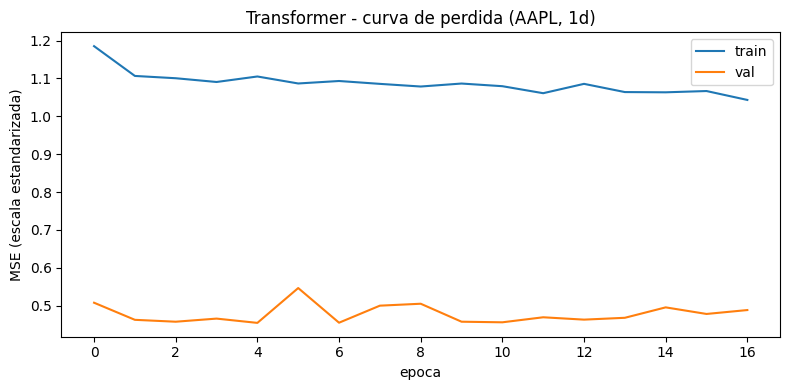

In [21]:
# Curva de entrenamiento (AAPL, 1d)
h = tf_hist[('AAPL', '1d')]
plt.figure(figsize=(8, 4))
plt.plot(h['train'], label='train')
plt.plot(h['val'], label='val')
plt.xlabel('epoca')
plt.ylabel('MSE (escala estandarizada)')
plt.title('Transformer - curva de perdida (AAPL, 1d)')
plt.legend()
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'transformer_loss_AAPL_1d.png', dpi=120)
plt.show()

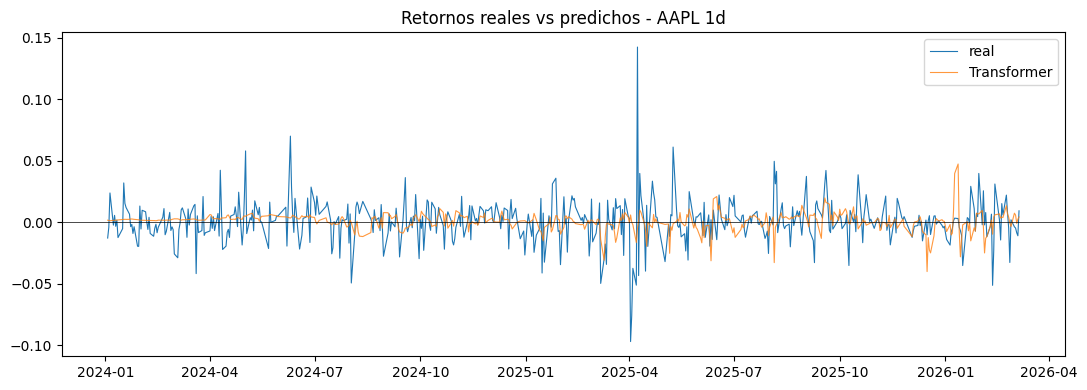

In [22]:
# Retornos reales vs predichos (AAPL, 1d)
t, horizon = 'AAPL', '1d'
yte = datasets[t][f'y_test_{horizon}'].values
yp = tf_preds[(t, horizon)]
idx = datasets[t]['idx_test'][:len(yte)]
plt.figure(figsize=(11, 4))
plt.plot(idx, yte, label='real', lw=0.8)
plt.plot(idx, yp, label='Transformer', lw=0.8, alpha=0.8)
plt.axhline(0, color='k', lw=0.5)
plt.title(f'Retornos reales vs predichos - {t} {horizon}')
plt.legend()
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'transformer_pred_AAPL_1d.png', dpi=120)
plt.show()

In [23]:
tf_df.to_csv(
    RESULTS_DIR / 'transformers_metricas.csv', index=False)
robust_df.to_csv(
    RESULTS_DIR / 'transformers_robustez.csv', index=False)
if not dm_df.empty:
    dm_df.to_csv(
        RESULTS_DIR / 'transformers_dm.csv', index=False)
print('Guardado en', RESULTS_DIR)
print(' - transformers_metricas.csv  (mismo esquema que '
      'metricas_regresion_v4.csv)')
print(' - transformers_robustez.csv')
print(' - transformers_dm.csv' if not dm_df.empty else '')

Guardado en C:\Users\enris\Desktop\UNIVERSIDAD\Cuarto\TFG\Resultados
 - transformers_metricas.csv  (mismo esquema que metricas_regresion_v4.csv)
 - transformers_robustez.csv
 - transformers_dm.csv


## 12. Como leer la comparacion

La fila `Transformer` de la tabla de la seccion 8 se lee junto a Naive,
ARIMA, Random Forest, XGBoost y LSTM **bajo el mismo protocolo**
(walk-forward, mismas variables, misma particion, mismas metricas). Lo
esperable, a la luz de la literatura y de los resultados del TFG:

- A **1 dia**, el Transformer deberia quedar al nivel del Naive en RMSE,
  con DA cuyo intervalo bootstrap cruza el 50 %. La auto-atencion no crea
  una senal que no existe.
- A **5 dias**, conviene mirar si iguala a XGBoost (el unico que bate al
  Naive en JPM/JNJ/XOM en el TFG) o si se queda corto.
- Frente a la **LSTM**, la comparacion directa de RMSE y DA dira si la
  atencion mejora a la recurrencia en este regimen de datos.

Andreoletti (2026) da la explicacion teorica: bajo perdida cuadratica y
estructura condicional debil (retornos), el predictor optimo es el
retorno cero; mas expresividad no reduce el sesgo, solo anade varianza.
Un Transformer que no gana al Naive no es un fallo de implementacion: es
lo que predice la teoria, y refuerza la tesis de eficiencia debil del
TFG.

### Referencias

Vaswani et al. (2017); Zeng et al. (2023, DLinear); Nie et al. (2023,
PatchTST); Liu et al. (2024, iTransformer); Kim et al. (2022, RevIN);
Andreoletti (2026, arXiv:2604.00064).